# In-Silico Mutagenesis and Scrambled Controls

Learn how to use supremo_lite's mutagenesis functions to:
- Generate saturation mutagenesis sequences for every position in a region
- Create targeted mutations around specific anchors or BED-defined regions
- Generate scrambled control sequences that preserve nucleotide composition

## Setup

In [1]:
import supremo_lite as sl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyfaidx import Fasta
from collections import Counter
import os

print(f"supremo_lite version: {sl.__version__}")

# Load test data
test_data_dir = "../../tests/data"
reference = Fasta(os.path.join(test_data_dir, "test_genome.fa"))

print(f"\nReference genome chromosomes:")
for chrom in reference.keys():
    print(f"  {chrom}: {len(reference[chrom])} bp")

supremo_lite version: 1.0.0

Reference genome chromosomes:
  chr1: 80 bp
  chr2: 80 bp
  chr3: 80 bp
  chr4: 80 bp
  chr5: 80 bp
  chr6: 80 bp


## Saturation Mutagenesis with get_sm_sequences()

Generate all possible single-nucleotide mutations for every position in a region. Each position gets 3 alternate alleles (the nucleotides that differ from reference).

In [2]:
# Mutate positions 10-20 on chr1
chrom = "chr1"
start, end = 10, 20

ref_seq, alt_seqs, metadata = sl.get_sm_sequences(
    chrom=chrom,
    start=start,
    end=end,
    reference_fasta=reference
)

print(f"Region: {chrom}:{start}-{end} ({end - start} bp)")
print(f"Reference sequence shape: {ref_seq.shape}")
print(f"Alternate sequences shape: {alt_seqs.shape}")
print(f"\nGenerated {len(metadata)} mutations (10 positions × 3 alternates)")
print(f"\nMetadata columns: {list(metadata.columns)}")
print(f"\nFirst 6 mutations:")
print(metadata.head(6).to_string(index=False))

Region: chr1:10-20 (10 bp)
Reference sequence shape: torch.Size([4, 10])
Alternate sequences shape: torch.Size([30, 4, 10])

Generated 30 mutations (10 positions × 3 alternates)

Metadata columns: ['chrom', 'window_start', 'window_end', 'variant_offset0', 'ref', 'alt']

First 6 mutations:
chrom  window_start  window_end  variant_offset0 ref alt
 chr1            10          20                0   T   A
 chr1            10          20                0   T   C
 chr1            10          20                0   T   G
 chr1            10          20                1   A   C
 chr1            10          20                1   A   G
 chr1            10          20                1   A   T


## Targeted Mutagenesis with get_sm_subsequences()

Mutate only specific regions within a larger sequence window. Two approaches:
1. **Anchor-based**: Center mutations around a specific position
2. **BED-based**: Mutate regions defined in a BED file

In [3]:
# Anchor-based: mutate positions within ±5 bp of position 40
ref_seq, alt_seqs, metadata = sl.get_sm_subsequences(
    chrom="chr1",
    seq_len=80,           # Full window length
    reference_fasta=reference,
    anchor=40,            # Center position
    anchor_radius=2       # Mutate positions 38-42
)

print(f"Anchor-based mutagenesis:")
print(f"  Window: 80 bp centered on position 40")
print(f"  Generated {len(metadata)} mutations (10 positions × 3 alternates)")
print(metadata.to_string(index=False))

Anchor-based mutagenesis:
  Window: 80 bp centered on position 40
  Generated 12 mutations (10 positions × 3 alternates)
chrom  window_start  window_end  variant_offset0 ref alt
 chr1             0          80               38   T   A
 chr1             0          80               38   T   C
 chr1             0          80               38   T   G
 chr1             0          80               39   G   A
 chr1             0          80               39   G   C
 chr1             0          80               39   G   T
 chr1             0          80               40   G   A
 chr1             0          80               40   G   C
 chr1             0          80               40   G   T
 chr1             0          80               41   A   C
 chr1             0          80               41   A   G
 chr1             0          80               41   A   T


In [4]:
# BED-based: mutate regions from a BED file
bed_df = pd.DataFrame({
    "chrom": ["chr1", "chr1"],
    "start": [10, 50],
    "end": [15, 55]
})

ref_seq, alt_seqs, metadata = sl.get_sm_subsequences(
    chrom="chr1",
    seq_len=80,
    reference_fasta=reference,
    bed_regions=bed_df
)

print(f"BED-based mutagenesis:")
print(f"  Region 1: chr1:10-15 (5 bp)")
print(f"  Region 2: chr1:50-55 (5 bp)")
print(f"  Generated {len(metadata)} mutations (10 positions × 3 alternates)")

BED-based mutagenesis:
  Region 1: chr1:10-15 (5 bp)
  Region 2: chr1:50-55 (5 bp)
  Generated 30 mutations (10 positions × 3 alternates)


## Scrambled Control Sequences

The `get_scrambled_subsequences()` function generates negative control sequences by scrambling BED-defined regions while **preserving nucleotide composition**. This is useful for:
- Creating matched controls that maintain GC content
- Disrupting regulatory motifs while keeping sequence properties
- Generating multiple scrambled versions for statistical analysis

In [5]:
# Define a region to scramble
bed_df = pd.DataFrame({
    "chrom": ["chr1"],
    "start": [20],
    "end": [60]      # 40 bp region to scramble
})

# Generate 5 scrambled versions
ref_seqs, scrambled_seqs, metadata = sl.get_scrambled_subsequences(
    chrom="chr1",
    seq_len=80,
    reference_fasta=reference,
    bed_regions=bed_df,
    n_scrambles=5,
    random_state=42     # For reproducibility
)

print(f"Scrambled subsequences:")
print(f"  Reference sequences: {ref_seqs.shape}")
print(f"  Scrambled sequences: {scrambled_seqs.shape}")
print(f"  Metadata rows: {len(metadata)}")
print(f"\nMetadata columns: {list(metadata.columns)}")

Scrambled subsequences:
  Reference sequences: torch.Size([1, 4, 80])
  Scrambled sequences: torch.Size([5, 4, 80])
  Metadata rows: 5

Metadata columns: ['chrom', 'window_start', 'window_end', 'scramble_start', 'scramble_end', 'scramble_idx', 'ref', 'alt']


In [6]:
# Examine the metadata
print("Scramble metadata:")
print(metadata.to_string(index=False))

Scramble metadata:
chrom  window_start  window_end  scramble_start  scramble_end  scramble_idx                                      ref                                      alt
 chr1             0          80              20            60             0 AATTACTCCTTTTGGAAATGGAACATTATGCGTTTTAAGA TCATAAACTTAGTATAGCTTGTCTAAGTAAATTGGTTAGC
 chr1             0          80              20            60             1 AATTACTCCTTTTGGAAATGGAACATTATGCGTTTTAAGA GGTTAAATTCGGATATAACATCTACATTTTTGGGTTACAA
 chr1             0          80              20            60             2 AATTACTCCTTTTGGAAATGGAACATTATGCGTTTTAAGA TTCATACTAAATTGATTGTATGTGTCGAAATTAAGGCATC
 chr1             0          80              20            60             3 AATTACTCCTTTTGGAAATGGAACATTATGCGTTTTAAGA TACCTTAATATAATGCGTATAGTGAATTAGCTTAAGGCTT
 chr1             0          80              20            60             4 AATTACTCCTTTTGGAAATGGAACATTATGCGTTTTAAGA TGCTTATATGTGTTGATTAATTCAAAAATGACGCAGTTAC


## Nucleotide Composition Preservation

The key property of scrambling is that it preserves nucleotide composition while disrupting sequence patterns.

In [7]:
# Get original and scrambled sequences from metadata
ref_region = metadata.iloc[0]["ref"]
alt_region = metadata.iloc[0]["alt"]

print(f"Reference sequence:  {ref_region}")
print(f"Scrambled sequence:  {alt_region}")
print(f"\nLength preserved: {len(ref_region)} == {len(alt_region)}")

# Count nucleotides
ref_counts = Counter(ref_region)
alt_counts = Counter(alt_region)

print(f"\nNucleotide counts:")
print(f"  Reference: A={ref_counts['A']}, C={ref_counts['C']}, G={ref_counts['G']}, T={ref_counts['T']}")
print(f"  Scrambled: A={alt_counts['A']}, C={alt_counts['C']}, G={alt_counts['G']}, T={alt_counts['T']}")
print(f"\nComposition preserved: {ref_counts == alt_counts}")

Reference sequence:  AATTACTCCTTTTGGAAATGGAACATTATGCGTTTTAAGA
Scrambled sequence:  TCATAAACTTAGTATAGCTTGTCTAAGTAAATTGGTTAGC

Length preserved: 40 == 40

Nucleotide counts:
  Reference: A=13, C=5, G=7, T=15
  Scrambled: A=13, C=5, G=7, T=15

Composition preserved: True


## K-mer Shuffling

The `kmer_size` parameter controls what level of sequence composition is preserved during scrambling:

| kmer_size | Shuffle Unit | Preserves |
|-----------|--------------|-----------|
| 1 (default) | Individual nucleotides | Nucleotide composition |
| 2 | Dinucleotides (2-mers) | Dinucleotide frequencies |
| 3 | Trinucleotides (3-mers) | Trinucleotide frequencies |

**Leftover Base Handling:** If the region length is not evenly divisible by the k-mer size, the remaining bases are treated as a partial k-mer and shuffled along with the complete k-mers. For example, a 15bp region with `kmer_size=2` produces 7 complete 2-mers plus 1 leftover base—all 8 chunks participate in the shuffle.

This is particularly useful when you need controls that maintain specific sequence properties like dinucleotide patterns or splice site motifs.

In [10]:
# Compare different k-mer shuffle sizes
# Using a 42bp region (divisible b 2 and 3) for clean k-mer preservation demo
bed_df = pd.DataFrame({
    "chrom": ["chr1"],
    "start": [20],
    "end": [62]      # 42 bp = divisible 2 and 3
})

def get_kmers(seq, k):
    """Count non-overlapping k-mers in a sequence."""
    return Counter([seq[i:i+k] for i in range(0, len(seq) - k + 1, k)])

print("Comparing k-mer shuffle sizes:\n")
print("=" * 70)

for k in [1, 2, 3]:
    _, _, meta = sl.get_scrambled_subsequences(
        chrom="chr1",
        seq_len=80,
        reference_fasta=reference,
        bed_regions=bed_df,
        n_scrambles=1,
        kmer_size=k,
        random_state=42
    )
    
    ref_region = meta.iloc[0]["ref"]
    alt_region = meta.iloc[0]["alt"]
    
    # Count k-mers (non-overlapping)
    ref_kmers = get_kmers(ref_region, k)
    alt_kmers = get_kmers(alt_region, k)
    kmer_preserved = ref_kmers == alt_kmers
    
    print(f"\nkmer_size={k}:")
    print(f"  Reference: {ref_region[:30]}...")
    print(f"  Scrambled: {alt_region[:30]}...")
    print(f"  {k}-mer frequencies preserved: {kmer_preserved}")

print("\n" + "=" * 70)
print("Note: Region length (42bp) is divisible by all k-mer sizes.")
print("With leftover bases, k-mer boundaries may shift, but all chunks")
print("(including partial k-mers) are still shuffled together.")

Comparing k-mer shuffle sizes:


kmer_size=1:
  Reference: AATTACTCCTTTTGGAAATGGAACATTATG...
  Scrambled: TAGTAATTCTCGGTAACATGTACTATATTA...
  1-mer frequencies preserved: True

kmer_size=2:
  Reference: AATTACTCCTTTTGGAAATGGAACATTATG...
  Scrambled: TTGACGGTATTGGATGTGTCAATTTTACGA...
  2-mer frequencies preserved: True

kmer_size=3:
  Reference: AATTACTCCTTTTGGAAATGGAACATTATG...
  Scrambled: TGGAACATGTTTAATTTTAGTCGTAAATCC...
  3-mer frequencies preserved: True

Note: Region length (42bp) is divisible by all k-mer sizes.
With leftover bases, k-mer boundaries may shift, but all chunks
(including partial k-mers) are still shuffled together.


> Note: Region length (42bp) is divisible by all k-mer sizes. With leftover bases, k-mer boundaries may shift, but all chunks (including partial k-mers) are still shuffled together.

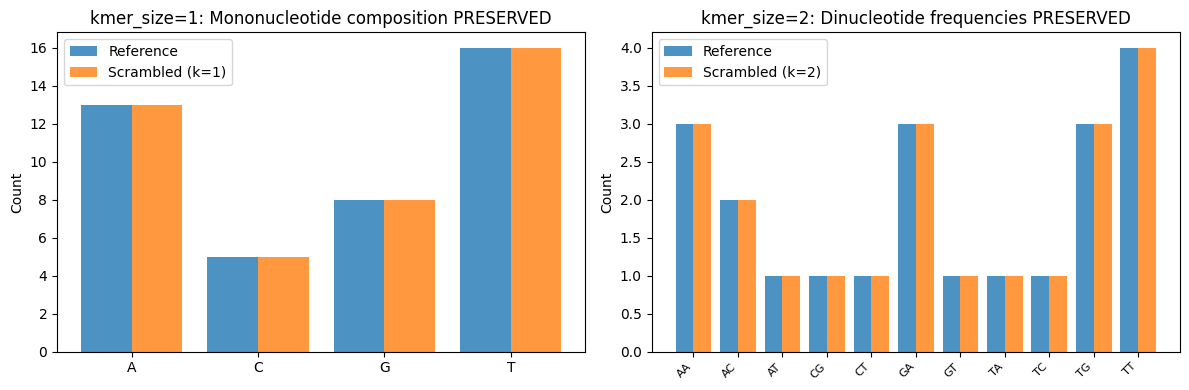

In [11]:
# Visualize k-mer preservation: k=1 preserves mononucleotides, k=2 preserves dinucleotides
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Use the same 42bp region from above
bed_df = pd.DataFrame({
    "chrom": ["chr1"],
    "start": [20],
    "end": [62]
})

# Get data for k=1 and k=2
results = {}
for k in [1, 2]:
    _, _, meta = sl.get_scrambled_subsequences(
        chrom="chr1", seq_len=80, reference_fasta=reference,
        bed_regions=bed_df, n_scrambles=1, kmer_size=k, random_state=42
    )
    results[k] = {
        'ref': meta.iloc[0]["ref"],
        'alt': meta.iloc[0]["alt"]
    }

ref_region = results[1]['ref']

# Plot mononucleotide counts for k=1
ref_mono = Counter(ref_region)
k1_mono = Counter(results[1]['alt'])
nucs = ['A', 'C', 'G', 'T']
x = range(len(nucs))
axes[0].bar([i - 0.2 for i in x], [ref_mono.get(n, 0) for n in nucs], 0.4, label='Reference', alpha=0.8)
axes[0].bar([i + 0.2 for i in x], [k1_mono.get(n, 0) for n in nucs], 0.4, label='Scrambled (k=1)', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(nucs)
axes[0].set_ylabel('Count')
axes[0].set_title('kmer_size=1: Mononucleotide composition PRESERVED')
axes[0].legend()

# Plot dinucleotide counts for k=2
ref_di = get_kmers(ref_region, 2)
k2_di = get_kmers(results[2]['alt'], 2)
dinucs = sorted(set(ref_di.keys()) | set(k2_di.keys()))
x = range(len(dinucs))
axes[1].bar([i - 0.2 for i in x], [ref_di.get(d, 0) for d in dinucs], 0.4, label='Reference', alpha=0.8)
axes[1].bar([i + 0.2 for i in x], [k2_di.get(d, 0) for d in dinucs], 0.4, label='Scrambled (k=2)', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(dinucs, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Count')
axes[1].set_title('kmer_size=2: Dinucleotide frequencies PRESERVED')
axes[1].legend()

plt.tight_layout()
plt.show()

## Visualizing Encoded Sequences

Compare the one-hot encoded reference and scrambled sequences to see how the scrambling affects the sequence pattern.

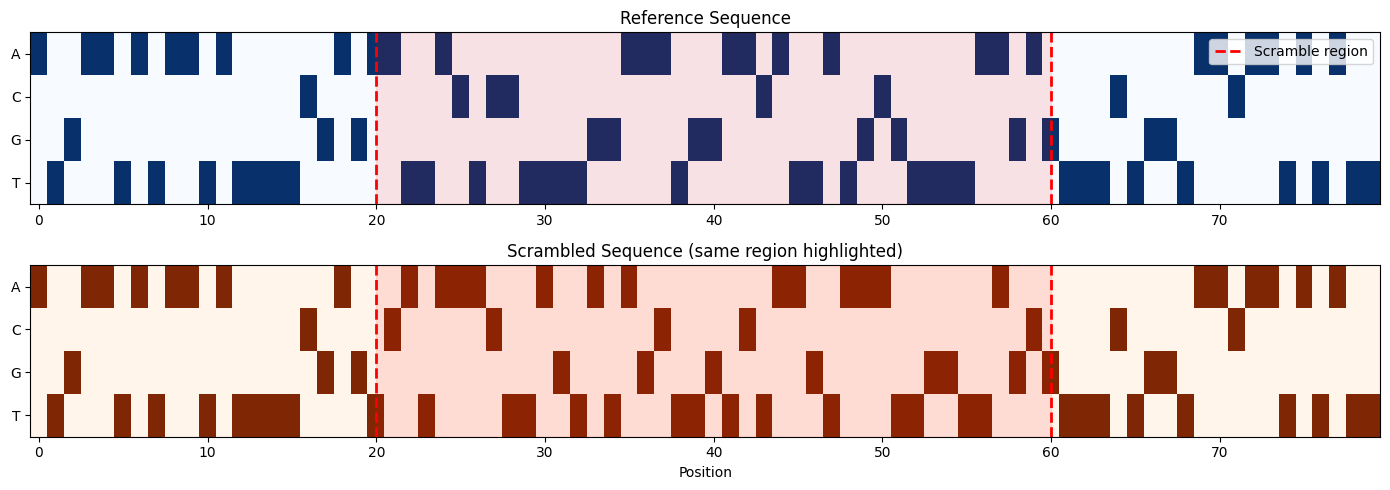

Scrambled region: positions 20-60
Regions outside the scramble boundaries remain identical.


In [11]:
# Get the scramble region boundaries
scram_start = int(metadata.iloc[0]['scramble_start'])
scram_end = int(metadata.iloc[0]['scramble_end'])

# Convert to numpy for visualization
ref_viz = ref_seqs[0].numpy() if hasattr(ref_seqs[0], 'numpy') else ref_seqs[0]
scram_viz = scrambled_seqs[0].numpy() if hasattr(scrambled_seqs[0], 'numpy') else scrambled_seqs[0]

fig, axes = plt.subplots(2, 1, figsize=(14, 5))

# Reference sequence
im1 = axes[0].imshow(ref_viz, cmap='Blues', aspect='auto')
axes[0].set_yticks([0, 1, 2, 3])
axes[0].set_yticklabels(['A', 'C', 'G', 'T'])
axes[0].set_title('Reference Sequence')
axes[0].axvline(x=scram_start, color='red', linestyle='--', linewidth=2, label='Scramble region')
axes[0].axvline(x=scram_end, color='red', linestyle='--', linewidth=2)
axes[0].axvspan(scram_start, scram_end, alpha=0.1, color='red')
axes[0].legend(loc='upper right')

# Scrambled sequence
im2 = axes[1].imshow(scram_viz, cmap='Oranges', aspect='auto')
axes[1].set_yticks([0, 1, 2, 3])
axes[1].set_yticklabels(['A', 'C', 'G', 'T'])
axes[1].set_title('Scrambled Sequence (same region highlighted)')
axes[1].set_xlabel('Position')
axes[1].axvline(x=scram_start, color='red', linestyle='--', linewidth=2)
axes[1].axvline(x=scram_end, color='red', linestyle='--', linewidth=2)
axes[1].axvspan(scram_start, scram_end, alpha=0.1, color='red')

plt.tight_layout()
plt.show()

print(f"Scrambled region: positions {scram_start}-{scram_end}")
print(f"Regions outside the scramble boundaries remain identical.")

## Next Steps

- **[01_getting_started.ipynb](01_getting_started.ipynb)** - Basic supremo_lite functionality
- **[02_personalized_genomes.ipynb](02_personalized_genomes.ipynb)** - Genome personalization workflows
- **[03_prediction_alignment.ipynb](03_prediction_alignment.ipynb)** - Align model predictions across variants
- **[04_pam_disruption.ipynb](04_pam_disruption.ipynb)** - CRISPR PAM disruption analysis
- **[Mutagenesis Guide](../user_guide/mutagenesis.md)** - Detailed documentation and API reference